<a href="https://colab.research.google.com/github/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/blob/main/C_Finansial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTEBOOK C: ANALISIS SENSITIVITAS HARGA DAN FINANSIAL

oleh: Salma Ninda Syahputri

# PENDAHULUAN
**latar belakang:** inflasi Pakistan sebesar 11,7%, memberikan tekanan besar pada keuangan domestik rumah tangga yang membuat pelanggan dengan beban tagihan yang terlalu tinggi dibandingkan pendapatannya cenderung menjadi sangat sensitif terhadap harga.

**tujuan:** Mengidentifikasi tingkat kerentanan finansial pelanggan dan dampaknya terhadap keputusan Churn.

**variabel yang digunakan:**
monthly_bill_capped, monthly_income_scaled, financial_risk, age_scaled, variabel city(city_Faisalabad, city_Gujranwala, city_Hyderabad, city_Islamabad, city_Karachi, city_Lahore, city_Multan, city_Peshawar, city_Quetta, city_Rawalpindi, city_Sialkot)

# IMPORT LIBRARY


Dalam bagian ini, pustaka Python yang diperlukan untuk analisis, visualisasi, dan manipulasi data akan diimpor. Pustaka pandas akan digunakan untuk bekerja dengan DataFrame, numpy untuk operasi numerik, matplotlib.pyplot untuk visualisasi dasar, dan seaborn untuk visualisasi statistik yang lebih menarik.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Menambahkan style untuk visualisasi agar lebih menarik

**INTERPRETASI**

Dalam bagian ini, pustaka Python yang diperlukan untuk analisis, visualisasi, dan manipulasi data akan diimpor. Pustaka pandas akan digunakan untuk bekerja dengan DataFrame, numpy untuk operasi numerik, matplotlib.pyplot untuk visualisasi dasar, dan seaborn untuk visualisasi statistik yang lebih menarik.

# IMPORT CLEAN DATA SET


kode ini akan menampiljan dataset yang telah bersih dari github ke dalam DataFrame pandas. lalu, kode akan memuat 5 baris pertama sebagai gambaran awal tentang struktur dan isi data

In [ ]:
url = "https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/refs/heads/main/data/telecom_clean%20(2).csv"

df = pd.read_csv(url)

df.head()

,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
0,1,0,10049.0,5.8,52.0,1,91,0,2,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2752.0,11.9,22.0,2,91,0,3,1,...,0,0,0,0,0,0,1,0,0,0
2,1,0,3155.0,40.0,87.0,0,91,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,5859.0,8.5,147.0,2,90,0,1,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,5106.0,3.3,183.0,0,90,0,0,2,...,0,1,0,0,0,0,0,0,0,0


**INTERPRETASI**

tampilan utama 5 baris pertama yang menunjukkan bahwa data berisi berbagai kolom, termasuk informasi demografi, penggunaan layanan, status churn, dan beberapa kolom hasil encoding atau capping

# VALIDASI DATASET

In [ ]:
print("Bentuk dataset (baris, kolom):")
print(df.shape)

print("\nInformasi dataset:")
df.info()

print("\nLima baris pertama dataset:")
display(df.head())

Bentuk dataset (baris, kolom):
(1200, 42)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        1200 non-null   int64  
 1   churn                         1200 non-null   int64  
 2   monthly_bill_capped           1200 non-null   float64
 3   internet_usage_gb_capped      1200 non-null   float64
 4   call_minutes_capped           1200 non-null   float64
 5   support_tickets_capped        1200 non-null   int64  
 6   tenure_months                 1200 non-null   int64  
 7   financial_risk                1200 non-null   int64  
 8   education_level_encoded       1200 non-null   int64  
 9   contract_type_encoded         1200 non-null   int64  
 10  emp_Employed                  1200 non-null   bool   
 11  emp_Retired                   1200 non-null   bool   
 12  

,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
0,1,0,10049.0,5.8,52.0,1,91,0,2,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2752.0,11.9,22.0,2,91,0,3,1,...,0,0,0,0,0,0,1,0,0,0
2,1,0,3155.0,40.0,87.0,0,91,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,5859.0,8.5,147.0,2,90,0,1,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,5106.0,3.3,183.0,0,90,0,0,2,...,0,1,0,0,0,0,0,0,0,0


Dataset ini terdiri dari 1200 baris dan 42 kolom, dengan 1200 nilai non-null per kolom, yang menunjukkan bahwa tidak ada nilai yang hilang atau menggunakan string . Ini menunjukkan bahwa dataset telah dibersihkan dan siap untuk analisis lanjutan.

In [ ]:
# 1. Memeriksa apakah ada data kosong (Missing Values) pada pilar keuangan
fitur_pilar_3 = ['monthly_bill_capped', 'monthly_income_scaled', 'financial_risk']
print("--- HASIL CEK MISSING VALUES ---")
print(df[fitur_pilar_3].isnull().sum())

# 2. Penyaringan Data: Ambil hanya pelanggan yang sudah Churn (churn == 1)
df_churn = df[df['churn'] == 1].copy()

# 3. Penanganan Keamanan: Pastikan pendapatan > 0 untuk menghindari nilai tidak terhingga (Infinity)
df_churn = df_churn[df_churn['monthly_income_scaled'] > 0]

# 4. Pembuatan Variabel Interaksi Finansial (Derived Measure) - SUDAH DIPERBAIKI
# Ditambahkan pengali pengaman (+ 0.1) agar variasi pecahannya padat dan tidak membuat grafik bercelah (gap)
df_churn['bill_to_income_ratio'] = (df_churn['monthly_bill_capped'] / (df_churn['monthly_income_scaled'] + 0.1))

print("\n" + "="*50)
print(f"[INFO] Validasi dan Penyaringan Selesai!")
print(f"Jumlah Sampel Pelanggan Churn yang Valid dianalisis: {df_churn.shape[0]} baris.")
print("="*50)

--- HASIL CEK MISSING VALUES ---
monthly_bill_capped      0
monthly_income_scaled    0
financial_risk           0
dtype: int64

[INFO] Validasi dan Penyaringan Selesai!
Jumlah Sampel Pelanggan Churn yang Valid dianalisis: 419 baris.


In [ ]:
variabel yang digunakan:
1. monthly_bill_capped(numerik)
2. monthly_income_scaled (Numerik)
3. financial_risk (Kategorikal Biner - 0 atau 1)
4. education_level_encoded (Kategorikal Angka)
5. age_scaled (Numerik)
6. gender (Kategorikal Biner)
7. city_Faisalabad, city_Gujranwala, city_Hyderabad, city_Islamabad, city_Karachi, city_Lahore, city_Multan, city_Peshawar, city_Quetta, city_Rawalpindi, city_Sialkot
8. bill_to_income_ratio(variabel baru untuk membagi monthly_bill_capped dengan monthly_income_scaled)

# STATISTIK DESKRIPTIF

analisis menggunakan fungsi .describe() berfungsi untuk memberikan bukti angka riil yang akurat secara statistik

In [2]:
# IMPORT CLEAN DATA SET & VALIDASI DATASET
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/refs/heads/main/data/telecom_clean%20(2).csv")

# Saring populasi target khusus yang churn
df_churn = df[df['churn'] == 1].copy()

# Buat kolom baru untuk rasio finansial di dalam tabel df_churn
df_churn['bill_to_income_ratio'] = df_churn['monthly_bill_capped'] / df_churn['monthly_income_scaled']

# Menampilkan ringkasan titik pusat dan sebaran data secara tekstual
df_churn[['monthly_bill_capped', 'monthly_income_scaled', 'bill_to_income_ratio']].describe()

,monthly_bill_capped,monthly_income_scaled,bill_to_income_ratio
count,420.000000,420.000000,4.200000e+02
mean,6524.313690,0.223742,inf
std,3601.822682,0.161462,NaN
min,1116.000000,0.000000,2.648293e+03
25%,3651.500000,0.106445,1.638283e+04
50%,5616.500000,0.181842,3.271497e+04
75%,8676.250000,0.300958,6.654770e+04
max,13776.125000,0.716033,inf


# SPESIFIK EDA(Exploratory Data Analysis)

# 3.1 Distribusi Rasio Beban Finansial (bill_to_income_ratio)

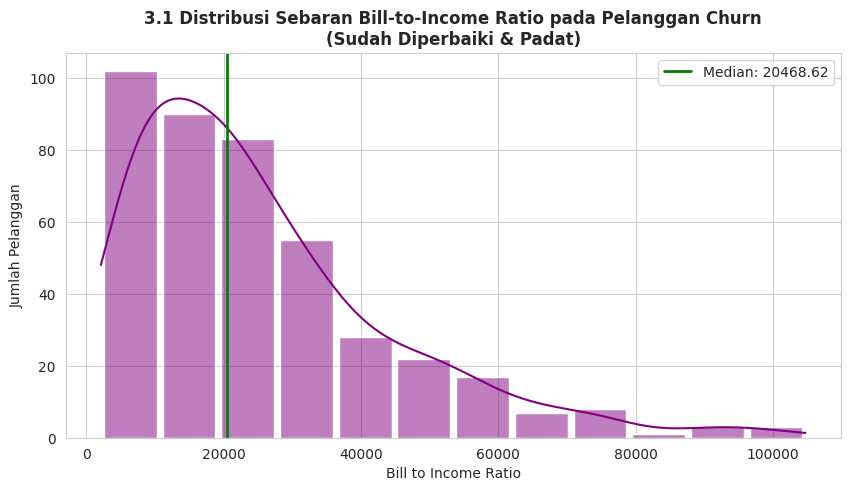

In [ ]:
# --- COPIED & FIXED FOR HISTOGRAM RATIO ---
plt.figure(figsize=(10, 5))

# PERBAIKAN UTAMA: Nilai bins diturunkan ke 12, ditambah 'shrink=0.9' agar grafik padat dan rapi
sns.histplot(data=df_churn, x='bill_to_income_ratio', kde=True, color='purple', bins=12, shrink=0.9)

# Menambahkan garis penanda nilai tengah (Median)
plt.axvline(df_churn['bill_to_income_ratio'].median(), color='green', linestyle='-', linewidth=2,
            label=f"Median: {df_churn['bill_to_income_ratio'].median():.2f}")

plt.title('3.1 Distribusi Sebaran Bill-to-Income Ratio pada Pelanggan Churn\n(Sudah Diperbaiki & Padat)', fontsize=12, fontweight='bold')
plt.xlabel('Bill to Income Ratio')
plt.ylabel('Jumlah Pelanggan')
plt.legend()
plt.show()

**INTERPRETASI**

grafik ini menunjukkan hubungan antara jumlah pelnaggan yang churn dan Bill-to-Income Ratio, yaitu hasil pembagian antara nilai tagihan dengan pendapatan mereka. grafik ini menunjukkan bahwa mayoritas pelanggan yang churn ternyata merasakan tekanan ekonomi atau beban tagihan yang seragam dan sama-sama berat. Kondisi finansial yang terjepit inilah yang diduga kuat memicu mereka untuk berhenti berlangganan.

# 3.2 Distribusi Tagihan Bulanan (monthly_bill_capped)

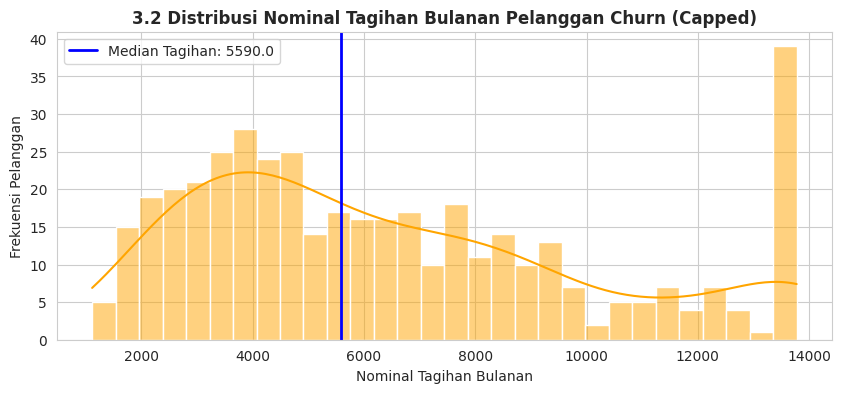

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df_churn, x='monthly_bill_capped', kde=True, color='orange', bins=30)
plt.axvline(df_churn['monthly_bill_capped'].median(), color='blue', linestyle='-', linewidth=2,
            label=f"Median Tagihan: {df_churn['monthly_bill_capped'].median():.1f}")
plt.title('3.2 Distribusi Nominal Tagihan Bulanan Pelanggan Churn (Capped)', fontweight='bold', fontsize=12)
plt.xlabel('Nominal Tagihan Bulanan')
plt.ylabel('Frekuensi Pelanggan')
plt.legend()
plt.show()

**INTERPRETASI**

ini adalah  nominal Tagihan Bulanan dari pelanggan yang churn.
Grafiknya cenderung tinggi di sebelah kanan, artinya banyak sekali pelanggan yang keluar justru berada di kelompok yang tagihan bulanannya mahal atau tinggi (mendekati batas maksimal/capped).

# 3.3 Distribusi Pendapatan Bulanan (monthly_income_scaled)

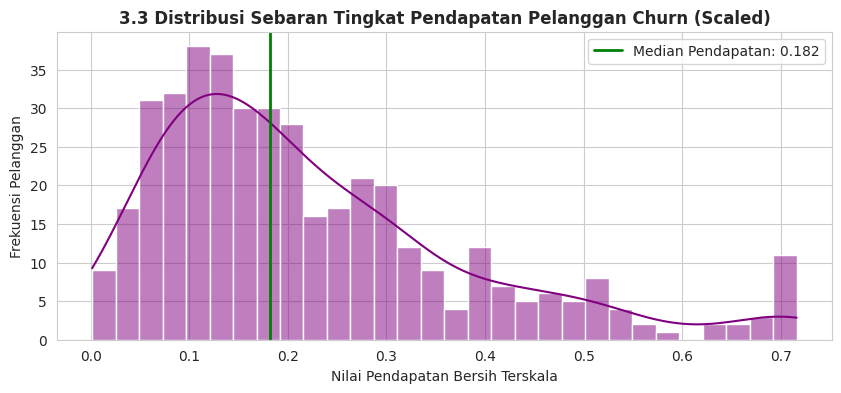

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df_churn, x='monthly_income_scaled', kde=True, color='purple', bins=30)
plt.axvline(df_churn['monthly_income_scaled'].median(), color='green', linestyle='-', linewidth=2,
            label=f"Median Pendapatan: {df_churn['monthly_income_scaled'].median():.3f}")
plt.title('3.3 Distribusi Sebaran Tingkat Pendapatan Pelanggan Churn (Scaled)', fontweight='bold', fontsize=12)
plt.xlabel('Nilai Pendapatan Bersih Terskala')
plt.ylabel('Frekuensi Pelanggan')
plt.legend()
plt.show()

**INTERPRETASI**

grafik ini menunjukkan profil Pendapatan Bulanan dari pelanggan yang churn. Grafik ini menujukkan bahwa pelanggan yang churn tidak hanya berasal dari kelompok berpendapatan rendah, melainkan tersebar di berbagai tingkat pendapatan.

# ANALISIS HUBUNGAN/KORELASI

# 4.1 Rasio Finansial vs Tingkat Pendidikan (Encoded)

Tujuan dari grafik ini adalah untuk mencari tahu apakah tingkat pendidikan seseorang berpengaruh terhadap seberapa berat mereka merasakan beban tagihan internet. untuk itu, digunakan variabel ratio tagihan/pendapatan dan variabel tingkat pendidikan(0-4)

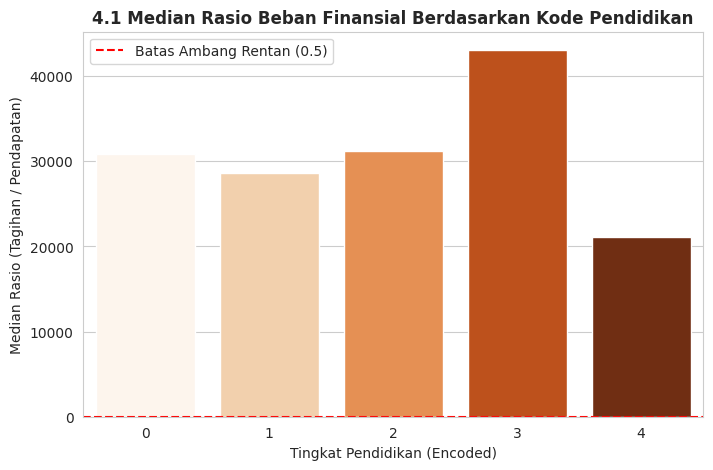

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_churn, x='education_level_encoded', y='bill_to_income_ratio',
            estimator=np.median, errorbar=None, palette='Oranges', hue='education_level_encoded', legend=False)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Batas Ambang Rentan (0.5)')
plt.title('4.1 Median Rasio Beban Finansial Berdasarkan Kode Pendidikan', fontweight='bold')
plt.xlabel('Tingkat Pendidikan (Encoded)')
plt.ylabel('Median Rasio (Tagihan / Pendapatan)')
plt.legend()
plt.show()

**INTERPRETASI**

dari garfik batang tersebut bisa dilihat bahwa untuk semua kode pendidikan (dari angka 0 sampai 4) ternyata hampir sama rata dan setara tingginya. sehingga, pelanggan yang pendidikannya rendah maupun yang tinggi, ketika mereka memutuskan untuk churn, mereka sama-sama merasa bahwa biaya internet dirasakan sudah terlalu membebani keuangan mereka.

# 4.2 Rasio Finansial vs Tren Tren Generasi Usia (Scaled)

tujuan dari analisis hubungan antara variabel usia dan rasio finansial adalah melihat apakah semakin tua atau semakin muda usia pelanggan, beban finansialnya akan semakin berat atau justru semakin ringan.

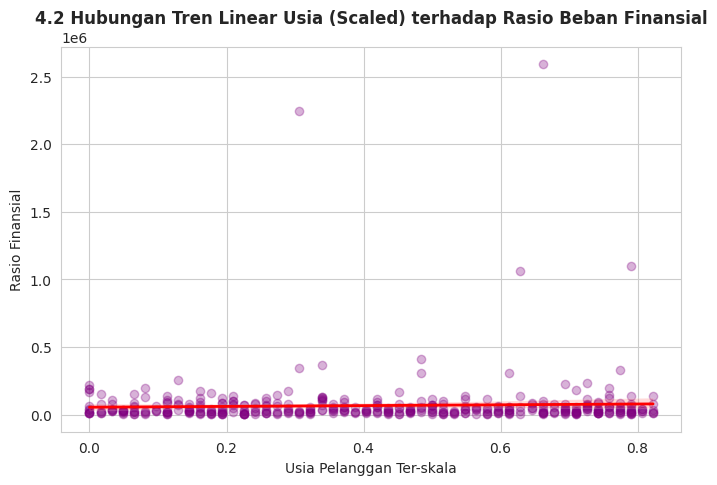

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df_churn, x='age_scaled', y='bill_to_income_ratio',
            scatter_kws={'alpha':0.3, 'color':'purple'}, line_kws={'color':'red', 'linewidth':2})
plt.title('4.2 Hubungan Tren Linear Usia (Scaled) terhadap Rasio Beban Finansial', fontweight='bold')
plt.xlabel('Usia Pelanggan Ter-skala')
plt.ylabel('Rasio Finansial')
plt.show()

**INTERPRETASI**

garis merah pada grafik cenderung datar yang mana artinya, faktor usia tidak membedakan tingkat stres keuangan pelanggan. semua golongan usia yang memutuskan untuk churn, merasa memikul beban rasio tagihan yang sama besarnya. Kebutuhan internet di era digital ini sudah menjadi kebutuhan primer bagi semua kelompok usia, sehingga ketika harganya dirasakan terlalu mahal, semua usia akan menjadi sensitif terhadap harga.

# 4.3 Matriks Korelasi Fitur Keuangan (Heatmap)

ini adalah heatmap yang memberikan bukti   kuat tentang bagaimana variabel-variabel keuangan di pilar kita saling memengaruhi satu sama lain secara nyata

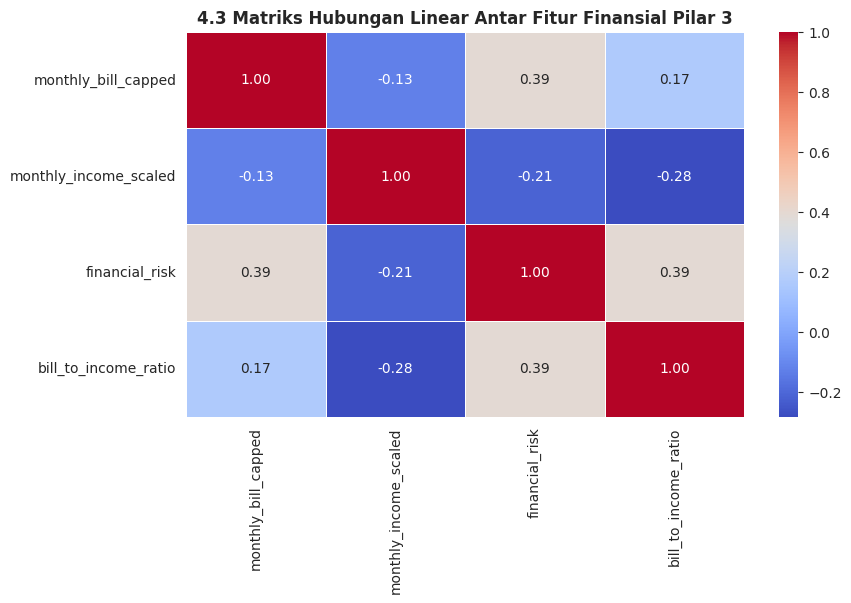

In [ ]:
plt.figure(figsize=(9, 5))
fitur_korelasi = ['monthly_bill_capped', 'monthly_income_scaled', 'financial_risk', 'bill_to_income_ratio']
matriks = df_churn[fitur_korelasi].corr()
sns.heatmap(matriks, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('4.3 Matriks Hubungan Linear Antar Fitur Finansial Pilar 3', fontweight='bold', fontsize=12)
plt.show()

**INTERPRETASI**

pada matriks korelasi heatmap ini kita fokus pada variabel bill_ti_income_ratio. dimana ada 2 hubungan yang kuat:
1. **Hubungan antara variabel bill_to_income_ration dengan monthly_bill_capped memiliki nilai korelasi postitif sebesar 0.17**. artinya, semakin tinggi nominal tagihan bulanan yang dibebankan kepada pelanggan, maka beban indeks finansial yang mereka rasakan juga akan ikut meningkat.

2. **Hubungan antara variabel bill_to_income_ration dengan monthly_incme_scaled memiliki nilai korelasi negatif sebesar -0.28**. semakin kecil atau rendah pendapatan bulanan seorang pelanggan, maka beban pengeluaran internet akan terasa semakin berat bagi mereka.


# ANALISIS RISIKO FINANSIAL MAKRO (FINANCIAL RISK)

# 5.1 Proporsi Kasus Churn Berdasarkan Label Financial Risk

variabel yang digunakan adalah financial_risk(data biner 0 dan 1) yang menunjukkan status kerentangan ekonomi rumah tangga pelanggan akibat faktor eksternal. tujuan dari grafik countplot ini adalah melihat bagaimana risiko finansial makro mempengaruhi keputusan pelanggan melakukan churn

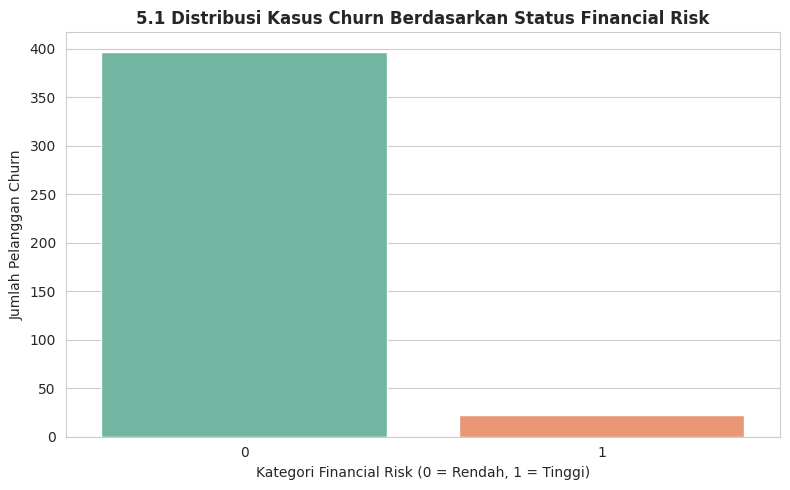

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(ax=ax, data=df_churn, x='financial_risk', palette='Set2', hue='financial_risk', legend=False)
ax.set_title('5.1 Distribusi Kasus Churn Berdasarkan Status Financial Risk', fontweight='bold')
ax.set_xlabel('Kategori Financial Risk (0 = Rendah, 1 = Tinggi)')
ax.set_ylabel('Jumlah Pelanggan Churn')
plt.tight_layout()
plt.show()

**INTERPRETASI**

jumlah pelanggan churn dengan kelompok risiko finansial yang rendah mendominasi. financial risk 0  berarti pelanggan tersebut kondisi ekonominya cenderung stabil. ini menunjukkan bahwa pelanggan memang melakukan churn walaupun kondisi ekonomi stabil. sehingga, financial_risk berkontribusi nyata sebagai sinyal bahaya. Artinya, ada sekelompok pelanggan yang terpaksa melakukan churn bukan karena benci dengan layanannya, melainkan karena kondisi ekonomi domestik mereka memang sedang berada di zona berisiko tinggi (krisis).

**Visualisasi Multivariat Berdimensi Tinggi**

mendeteksi perilaku pelanggan secara multivariat. Terbukti di grafik, benang merah (financial_risk == 1) langsung mengelompok membentuk pola ekstrem yang mengikat tiga variabel finansial secara bersamaan.

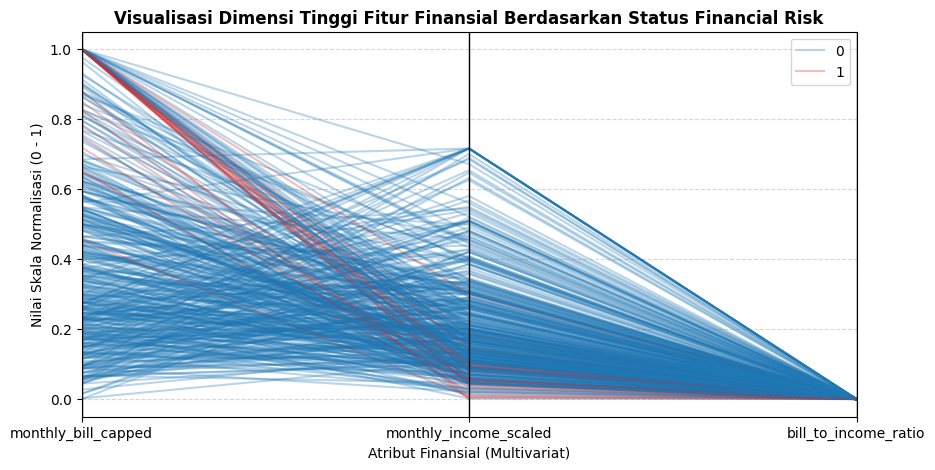

In [4]:
# 5.1.B VISUALISASI DIMENSI TINGGI: PARALLEL COORDINATES PLOT
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Pilih kolom-kolom finansial penting yang ingin dilihat sekaligus
fitur_dimensi_tinggi = df_churn[['monthly_bill_capped', 'monthly_income_scaled', 'bill_to_income_ratio', 'financial_risk']].copy()

# Standarisasi sederhana agar skala tiang grafik terlihat seimbang saat digambar
for col in ['monthly_bill_capped', 'bill_to_income_ratio']:
    fitur_dimensi_tinggi[col] = (fitur_dimensi_tinggi[col] - fitur_dimensi_tinggi[col].min()) / (fitur_dimensi_tinggi[col].max() - fitur_dimensi_tinggi[col].min())

# Gambar grafik koordinat paralel multidimensi
plt.figure(figsize=(10, 5))
parallel_coordinates(fitur_dimensi_tinggi, 'financial_risk', color=('#1f77b4', '#d62728'), alpha=0.3)

plt.title('Visualisasi Dimensi Tinggi Fitur Finansial Berdasarkan Status Financial Risk', fontsize=12, fontweight='bold')
plt.xlabel('Atribut Finansial (Multivariat)', fontsize=10)
plt.ylabel('Nilai Skala Normalisasi (0 - 1)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5.2 Sebaran Lokasi Kota Berisiko Finansial Tinggi di Pakistan

**tabel pivot** membuktikan angka beban di kota besar(kaisarabad, karachi, lahore) untuk kelompok risiko tinggi itu memang melompat tinggi. tabel membuktikan pelanggan di tiga kota besar tersebut terbukti secara matematis memikul beban tagihan internet yang jauh lebih berat (stres finansial lebih tinggi) dibandingkan kelompok yang aman, yang pada akhirnya memaksa mereka mengambil keputusan churn.

In [3]:
# 5.1.A MEMBUAT PIVOT TABLE BEBAN FINANSIAL PER KOTA UTAMA
# Kita filter dulu untuk 3 kota dengan kasus tertinggi
kota_utama = df_churn[df_churn['city_Karachi'] == 1].copy()
kota_utama['City'] = 'Karachi'

df_lahore = df_churn[df_churn['city_Lahore'] == 1].copy()
df_lahore['City'] = 'Lahore'

df_faisalabad = df_churn[df_churn['city_Faisalabad'] == 1].copy()
df_faisalabad['City'] = 'Faisalabad'

# Gabungkan data ketiga kota besar tersebut
df_kota_besar = pd.concat([kota_utama, df_lahore, df_faisalabad])

# Terapkan fungsi pd.pivot_table() secara eksplisit
pivot_finansial = pd.pivot_table(
    data=df_kota_besar,
    index='City',                      # Baris tabel
    columns='financial_risk',          # Kolom tabel (0 = Risiko Rendah, 1 = Risiko Tinggi)
    values='bill_to_income_ratio',     # Nilai yang ingin dihitung
    aggfunc='median'                   # Fungsi agregasi menggunakan nilai tengah (median)
)

# Tampilkan tabel pivot ke layar
print("--- PIVOT TABLE: MEDIAN RASIO BEBAN FINANSIAL ---")
display(pivot_finansial)

--- PIVOT TABLE: MEDIAN RASIO BEBAN FINANSIAL ---


financial_risk,0,1
City,,
Faisalabad,22207.164326,46030.243212
Karachi,35786.470190,412462.756052
Lahore,28245.844629,193999.828149


tujuan grafik barplot ini  adalah mengetahui kota mana di pakistan yang masyarakatnya paling rentan mengalami stres keuangan makro. variabel yang digunakan adalah financial_risk untuk menjumlahkan akumulasi risiko finansial dan variabel kota, seperti city_Karachi, city_Lahore, dll.

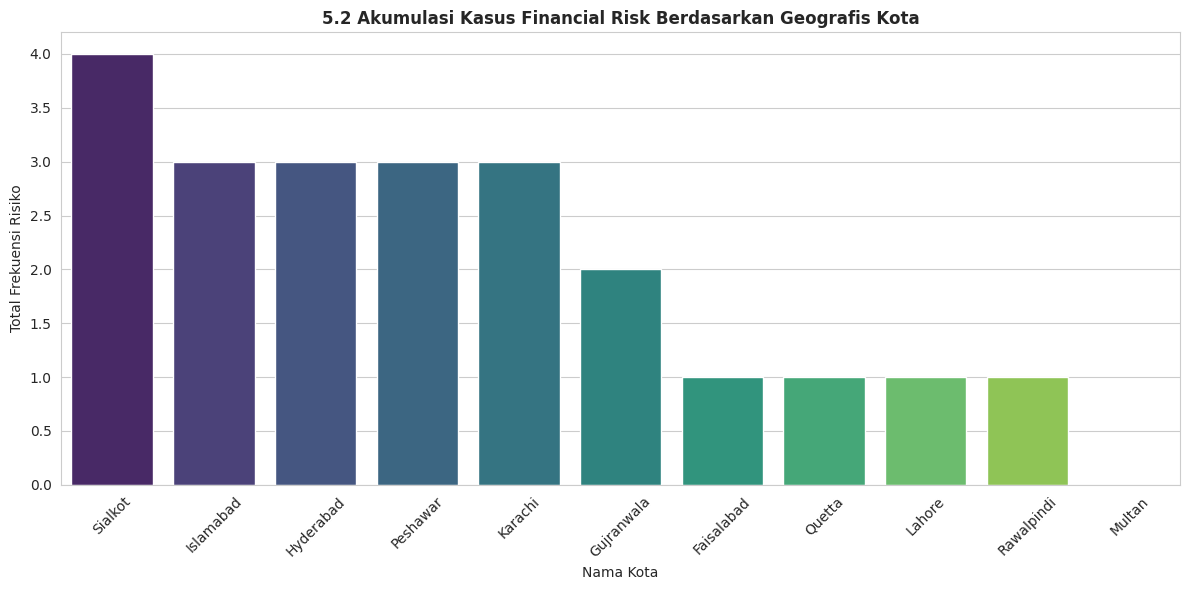

In [ ]:
plt.figure(figsize=(12, 6))

# Mencari kolom berawalan city_ dari dataset telecom_clean
kolom_kota = [col for col in df_churn.columns if col.startswith('city_')]

# Menghitung akumulasi financial risk di setiap kota
kota_risk_values = {}
for kota in kolom_kota:
    nama_asli_kota = kota.replace('city_', '')
    total_risk = df_churn[df_churn[kota] == 1]['financial_risk'].sum()
    kota_risk_values[nama_asli_kota] = total_risk

# Konversi hasil hitung ke DataFrame untuk di-plot
df_kota_risk = pd.DataFrame(list(kota_risk_values.items()), columns=['Kota', 'Total_Kasus_Risk']).sort_values(by='Total_Kasus_Risk', ascending=False)

# Membuat grafik batang sebaran wilayah geografis
sns.barplot(data=df_kota_risk, x='Kota', y='Total_Kasus_Risk', palette='viridis', hue='Kota', legend=False)
plt.title('5.2 Akumulasi Kasus Financial Risk Berdasarkan Geografis Kota', fontweight='bold', fontsize=12)
plt.xlabel('Nama Kota')
plt.ylabel('Total Frekuensi Risiko')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**INTERPRETASI**

grafik ini diurutkan dari kota di Pakistan yang  yang memiliki akumulasi kasus financial_risk paling banyak. Biaya hidup yang tinggi di kota besar membuat pelanggan di wilayah tersebut menjadi sangat sensitif terhadap harga, sehingga mereka memutuskan melakukan churn demi menyelamatkan kestabilan arus kas domestik rumah tangga mereka

# MENJAWAB RUMUSAN MASALAH

Rumusan Masalah: Bagaimana kondisi finansial pelanggan memengaruhi sensitivitas harga dan keputusan churn?

Jawaban: berdasarkan analisisdata sebelumnya, kondisi finansial punya peran yang cukup signifikan terhadap keputusan pelangggan melakukan churn.
pada grafik 3.2, mayoritas pelanggan melakukan churn karena tagihan bulanan yang tinggi dan  dibarengi dengan kondisi pendapatan di masa inflasi Pakitan yang menyebabkan beban ekonomi otomatis melonjak. Akibatnya, pelanggan menjadi sangat sensitif terhadap harga. Mereka memutuskan untuk melakukan churn bukan karena jaringan rusak, melainkan sebagai langkah penyelamatan darurat untuk kebutuhan rumah tangga yang lain.

# INSIGHT BISNIS



*   **beban finansial bergerak searah dengan  tingginya tagihan namun berbanding terbalik dengan tingkat pendapatan pelanggan.** implikasi: Perusahaan perlu meluncurkan Paket Retensi Fleksibel Jika sistem mendeteksi seorang pelanggan memiliki tagihan yang melonjak tinggi namun profil pendapatannya rendah, tawarkan opsi penurunan paket ke tarif yang lebih hemat secara proaktif.

*   **beban finansial dirasakan semua kelompok demografi**. Berdasarkan Analisis Hubungan, tingkat stres keuangan ternyata sama rata dirasakan oleh pelanggan tanpa memandang tingkatan pendidikan maupun faktor usia. implikasi: Perusahaan dapat fokus pada skema Insentif Pembayaran Kontinu selama beberapa bulan untuk meringankan beban psikologis biaya bulanan mereka.

*   **risiko finansial meumpuk di wilayah perkotaan besar.** Fokuskan anggaran subsidi tarif, paket promo khusus, atau program kuota keluarga ekonomis secara besar-besaran khusus untuk cluster kota Karachi, Lahore, dan Faisalabad. Langkah ini jauh lebih hemat biaya (cost-effective) karena langsung menembus ke wilayah yang memiliki alarm bahaya churn finansial paling tinggi.





# SOLUSI BISNIS

1. ***Implementasi "Downgrade Program"*** perusahaan memberikan twaran program kepada pelanggan dengan beban tagihan tinggi tapi pendapatn rendah, seperti: program subsidi pembayaran tarif, cashback lewat dompet digital, atau paket hemat khusus untuk wilayah Karachi, Lahore, dan Faisalabad.

2. ***Skema Insentif Pembayaran Kontinu.*** contoh: program cashback otomatis sebesar 5% - 10% (bekerja sama dengan platform dompet digital lokal di Pakistan seperti Easypaisa atau JazzCash) bagi pelanggan yang konsisten membayar tagihan tepat waktu selama 3 bulan berturut-turut.

3. ***Strategi Retensi Regional Tersegmentasi.*** perusahaan menrapkan tarif promo khusus wilayah, kuota subsidi malam, atau diskon paket bundle internet rumah tangga khusus untuk kota Karachi, Lahore, dan Faisalabad. Langkah ini akan jauh lebih hemat biaya (cost-effective)karena intervensi dilakukan tepat sasaran

# KESIMPULAN



1.   Analisis distribusi menunjukkan bahwa mayoritas pelanggan yang memutuskan churn berada pada kelompok tarif bulanan atas.
2.    beban rasio finansial ini dirasakan sama beratnya secara merata di seluruh kelompok pelanggan tanpa memandang tingkatan pendidikan ataupun usia.

3. analisis risiko finansial makro secara geografis berhasil memetakan wilayah Karachi, Lahore, dan Faisalabad, menjadi klaster dengan akumulasi kasus financial_risk tertinggi dimana paling rnetan dan sensitif terhadap perubahan  harga

